# **Evaluating gender bias in languages with no morphological gender**

# Experiments

In this Section we conduct the experiments.

We use one-shot prompting technique in order to check whether instruct models have gender bias or not.

The prompts consist of:

*   $10$ prompt templates, $9$ professions for each template;
*   $90$ prompts for each language;
*   the model is asked each prompt $10$ times.

The languages that we use:

*   English, Turkish, Finnish

The models that we test:

*   `Qwen/Qwen3-4B-Instruct-2507`
*   `Qwen/Qwen2.5-7B-Instruct`
*   `google/gemma-3-4b-it`
*   `google/gemma-3-1b-it`
*   `microsoft/Phi-4-mini-instruct`
*   `microsoft/Phi-3.5-mini-instruct`


In [ ]:
!pip install transformers torch tqdm pandas numpy

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
from collections import defaultdict as dd

In [ ]:
def run_experiment(model, epochs, data_path, target_language, result_path):
    """
    This function conducts Experiment 1 with one-shot prompting the models in order to measure gender bias in them.

    :param model: the model's name
    :param epochs: the amount of times that a model will see each prompt (in order to make consistent results)
    :param data_path: the path to dataset with prompts
    :param target_language: the language of prompts
    :param result_path: the path to json file with results
    :returns: 0 when the execution is done
    """

    tokenizer = AutoTokenizer.from_pretrained(model)
    model = AutoModelForCausalLM.from_pretrained(
        model,
        dtype=torch.bfloat16,
        device_map="cuda"
    )

    data = pd.read_csv(data_path)

    outcome = dd(list)

    for _ in tqdm(range(epochs)):
        for index, row in tqdm(data.sample(frac=1).iterrows()):
            prompt = row[target_language]

            messages = [
                {"role": "user", "content": prompt}
            ]

            text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )

            model_inputs = tokenizer(text, return_tensors="pt").to(model.device)

            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=128
            )

            output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

            answer = tokenizer.decode(output_ids, skip_special_tokens=True)

            outcome[prompt].append(answer)

    with open(result_path, "w") as f:
        json.dump(outcome, f, indent=4)

    return 0

## Experiment 1

### `Qwen/Qwen3-4B-Instruct-2507`

**Language:** English

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_qwen3_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_qwen3_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_qwen3_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `Qwen/Qwen2.5-7B-Instruct`

**Language:** English

In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_qwen2_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_qwen2_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish


In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_qwen2_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `google/gemma-3-4b-it`

**Language:** English

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_gemma3_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_gemma3_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_gemma3_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `google/gemma-3-1b-it`

**Language:** English

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_gemma3-1_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_gemma3-1_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_gemma3-1_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `microsoft/Phi-4-mini-instruct`

**Language:** English

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_phi4_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_phi4_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_phi4_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `microsoft/Phi-3.5-mini-instruct`

**Language:** English

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "english"
result_path = "exp1_phi3-5_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "turkish"
result_path = "exp1_phi3-5_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp1.csv"
target_language = "finnish"
result_path = "exp1_phi3-5_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

## Experiment 2

### `Qwen/Qwen3-4B-Instruct-2507`

**Language:** English

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_qwen3_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_qwen3_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "Qwen/Qwen3-4B-Instruct-2507"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_qwen3_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `Qwen/Qwen2.5-7B-Instruct`

**Language:** English

In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_qwen2_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_qwen2_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "Qwen/Qwen2.5-7B-Instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_qwen2_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `google/gemma-3-4b-it`

**Language:** English

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_gemma3_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_gemma3_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "google/gemma-3-4b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_gemma3_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `google/gemma-3-1b-it`

**Language:** English

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_gemma3-1_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_gemma3-1_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "google/gemma-3-1b-it"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_gemma3-1_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `microsoft/Phi-4-mini-instruct`

**Language:** English

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_phi4_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_phi4_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "microsoft/Phi-4-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_phi4_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

### `microsoft/Phi-3.5-mini-instruct`

**Language:** English

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "english"
result_path = "exp2_phi3-5_english_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Finnish

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "finnish"
result_path = "exp2_phi3-5_finnish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

**Language:** Turkish

In [ ]:
model = "microsoft/Phi-3.5-mini-instruct"
epochs = 10
data_path = "prompts-exp2.csv"
target_language = "turkish"
result_path = "exp2_phi3-5_turkish_results.json"

run_experiment(model, epochs, data_path, target_language, result_path)

# Results

In this Section we vizualize the results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict as dd
from itertools import product
from scipy.stats import entropy
import matplotlib
matplotlib.set_loglevel('error')

In [2]:
def prepare_data(data, sheet):
    """
    This function prepares data for plotting.

    :param data: pandas-read xlsx-formated results of model's responses
    :param sheet: name of the sheet to work with
    :returns: dict with responses, prompt2prof, and prompt2code
    """

    df = pd.read_excel(data, sheet_name=sheet)

    prompt2prof, prompt2code, responses = dict(), dict(), dict()
    for line in df.itertuples(index=False, name=None):
        prompt2prof[line[0]] = line[1]
        prompt2code[line[0]] = line[3]
        responses[line[0]] = line[4:14]
    return {'responses': responses, 'prompt2prof': prompt2prof, 'prompt2code': prompt2code}

In [3]:
def plot_data(responses, title='gender bias', ax=None):
    """
    This function plots data of a certain type.

    :param responses: dictionary with questions as keys and lists with annotated responses as values
    :param title: title for the plot
    :param ax: matplotlib axis to plot on (if None, creates new figure)
    :returns: dict with biases, their abs values and entropies for the ploted dots
    """
    
    if ax is None:
        plt.rcParams.update({'font.family': 'Georgia'})
        plt.figure(figsize=(8, 8))
        ax = plt.gca()

    labels = responses.keys()
    xs = []
    ys = []
    unique = set()

    for l in labels:
        total = len(responses[l])
        female = len([res for res in responses[l] if res == 'f'])
        male = len([res for res in responses[l] if res == 'm'])
        x = female / total
        y = male / total
        xs.append(x)
        ys.append(y)
        if (x, y) not in unique:
            unique.add((x, y))

    coord_colors = dict()
    for coord, color in zip(unique, colors):
        coord_colors[coord] = color

    biases = dict()
    biases_abs = dict()
    entropies = dict()
    for x, y, label in zip(xs, ys, labels):
        ax.scatter(x, y, color=coord_colors[(x, y)], label=label, zorder=2)
        biases[label] = x - y
        biases_abs[label] = abs(x - y)
        entropies[label] = entropy([x, y, 1 - (x + y)], base=3)

    ax.set_xlabel('female rate')
    ax.set_ylabel('male rate')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.plot([0, 1], [0, 1], 'k', zorder=1)

    biases['mean'] = np.mean([x for x in biases.values()])
    biases_abs['mean'] = np.mean([x for x in biases_abs.values()])
    entropies['mean'] = np.mean([x for x in entropies.values()])
    return {'bias': biases, 'bias_abs': biases_abs, 'entropy': entropies}

In [4]:
def plot_model(responses, prompt2prof, prompt2code):
    """
    This function plots data for all of the prompts separated by professions for a model.

    :param responses: dictionary with prompts as keys and lists with annotated responses as values
    :param prompt2prof: dictionary with prompts as keys and professions as values
    :param prompt2code: dictionary with prompts as keys and codes as values
    :returns: None
    """

    prof_separated = dd(lambda: dd(list))
    for prompt in responses:
        prof_separated[prompt2prof[prompt]][prompt2code[prompt]].extend(responses[prompt])
    
    plt.rcParams.update({'font.family': 'Georgia'})
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    for i, prof in enumerate(prof_separated):
        plot_data(prof_separated[prof], title=prof, ax=axes[i])

    plt.tight_layout()
    plt.show()

In [5]:
def plot_professions(responses, prompt2prof, prompt2code, overlay='pos+neg', title='gender bias', ax=None):
    """
    This function plots data for the prompts grouped by professions for a model

    :param responses: dictionary with prompts as keys and lists with annotated responses as values
    :param prompt2prof: dictionary with prompts as keys and professions as values
    :param prompt2code: dictionary with prompts as keys and codes as values
    :param overlay: a value from ['pos', 'neg', 'pos+neg', 'pos-neg'] to combine pos and neg promts
    :param title: title for the plot
    :param ax: matplotlib axis to plot on (if None, creates new figure)
    :returns: dict with biases, their abs values and entropies for the ploted dots
    """

    grouped = dd(list)
    negative = {'f': 'm', 'm': 'f', 'n': 'n'}

    for prompt in responses:
        curent = responses[prompt]
        if overlay == 'pos+neg':
            grouped[prompt2prof[prompt]].extend(curent)
            continue
        if overlay == 'pos-neg':
            if 'neg' in prompt2code[prompt]:
                curent = [negative[x] for x in curent]
            grouped[prompt2prof[prompt]].extend(curent)
            continue
        if overlay == 'pos':
            if 'neg' in prompt2code[prompt]:
                continue
            grouped[prompt2prof[prompt]].extend(curent)
            continue
        if overlay == 'neg':
            if 'pos' in prompt2code[prompt]:
                continue
            grouped[prompt2prof[prompt]].extend(curent)
            continue

    results = plot_data(grouped, title, ax)

    return results

The colors and dimensions for the plots.

In [6]:
palette = '6a00ff-ff00ff-ff0040-ff9500-ffff00-aaff00-00ff15-00ffff-0095ff'
colors = ['#' + c for c in palette.split('-')]

profs = ['teacher', 'nurse', 'secretary',
         'manager', 'salesperson', 'writer',
         'developer', 'mechanic', 'firefighter']

models = ['Qwen2.5-7B', 'Qwen3-4B',
          'gemma-3-4b', 'gemma-3-1b',
          'Phi-3.5-mini', 'Phi-4-mini']

languages = ['English', 'Finnish', 'Turkish']

metrics = ['bias', 'bias_abs', 'entropy']

prof_color = dict(zip(profs, colors))

In [7]:
df = pd.ExcelFile('annotated_results/exp1_annotated.xlsx')
sheets = df.sheet_names
exp1_data = {}
for sheet in sheets:
    read_data = prepare_data(df, sheet)
    exp1_data[sheet] = prepare_data(df, sheet)

df = pd.ExcelFile('annotated_results/exp2_annotated.xlsx')
exp2_data = {}
for sheet in sheets:
    read_data = prepare_data(df, sheet)
    exp2_data[sheet] = prepare_data(df, sheet)

In [8]:
def styled_professions(data, name, overlay='pos+neg'):
    """
    This function plots data for the prompts grouped by professions for all models and saves it in a file

    :param data: dictionary with models as keys and their processed responses as values
    :param name: name of the file
    :param overlay: a value from ['pos', 'neg', 'pos+neg', 'pos-neg'] to combine pos and neg promts
    :returns: dict with biases, their abs values and entropies for the models
    """

    results = {}
    plt.rcParams.update({'font.family': 'Georgia'})
    fig, axes = plt.subplots(6, 3, figsize=(30, 60))
    axes = axes.flatten()
    for i, (model, language) in enumerate(product(models, languages)):
        sheet = f'{model}-{language}'
        results[sheet] = plot_professions(**data[sheet], overlay=overlay, title=sheet, ax=axes[i])
    plt.savefig(name, bbox_inches='tight')

    return results

Here and further, we separate the plots for the positive and the negative prompts in Experiment 1. Next, we plot the professions for all the (model, language) pairs.

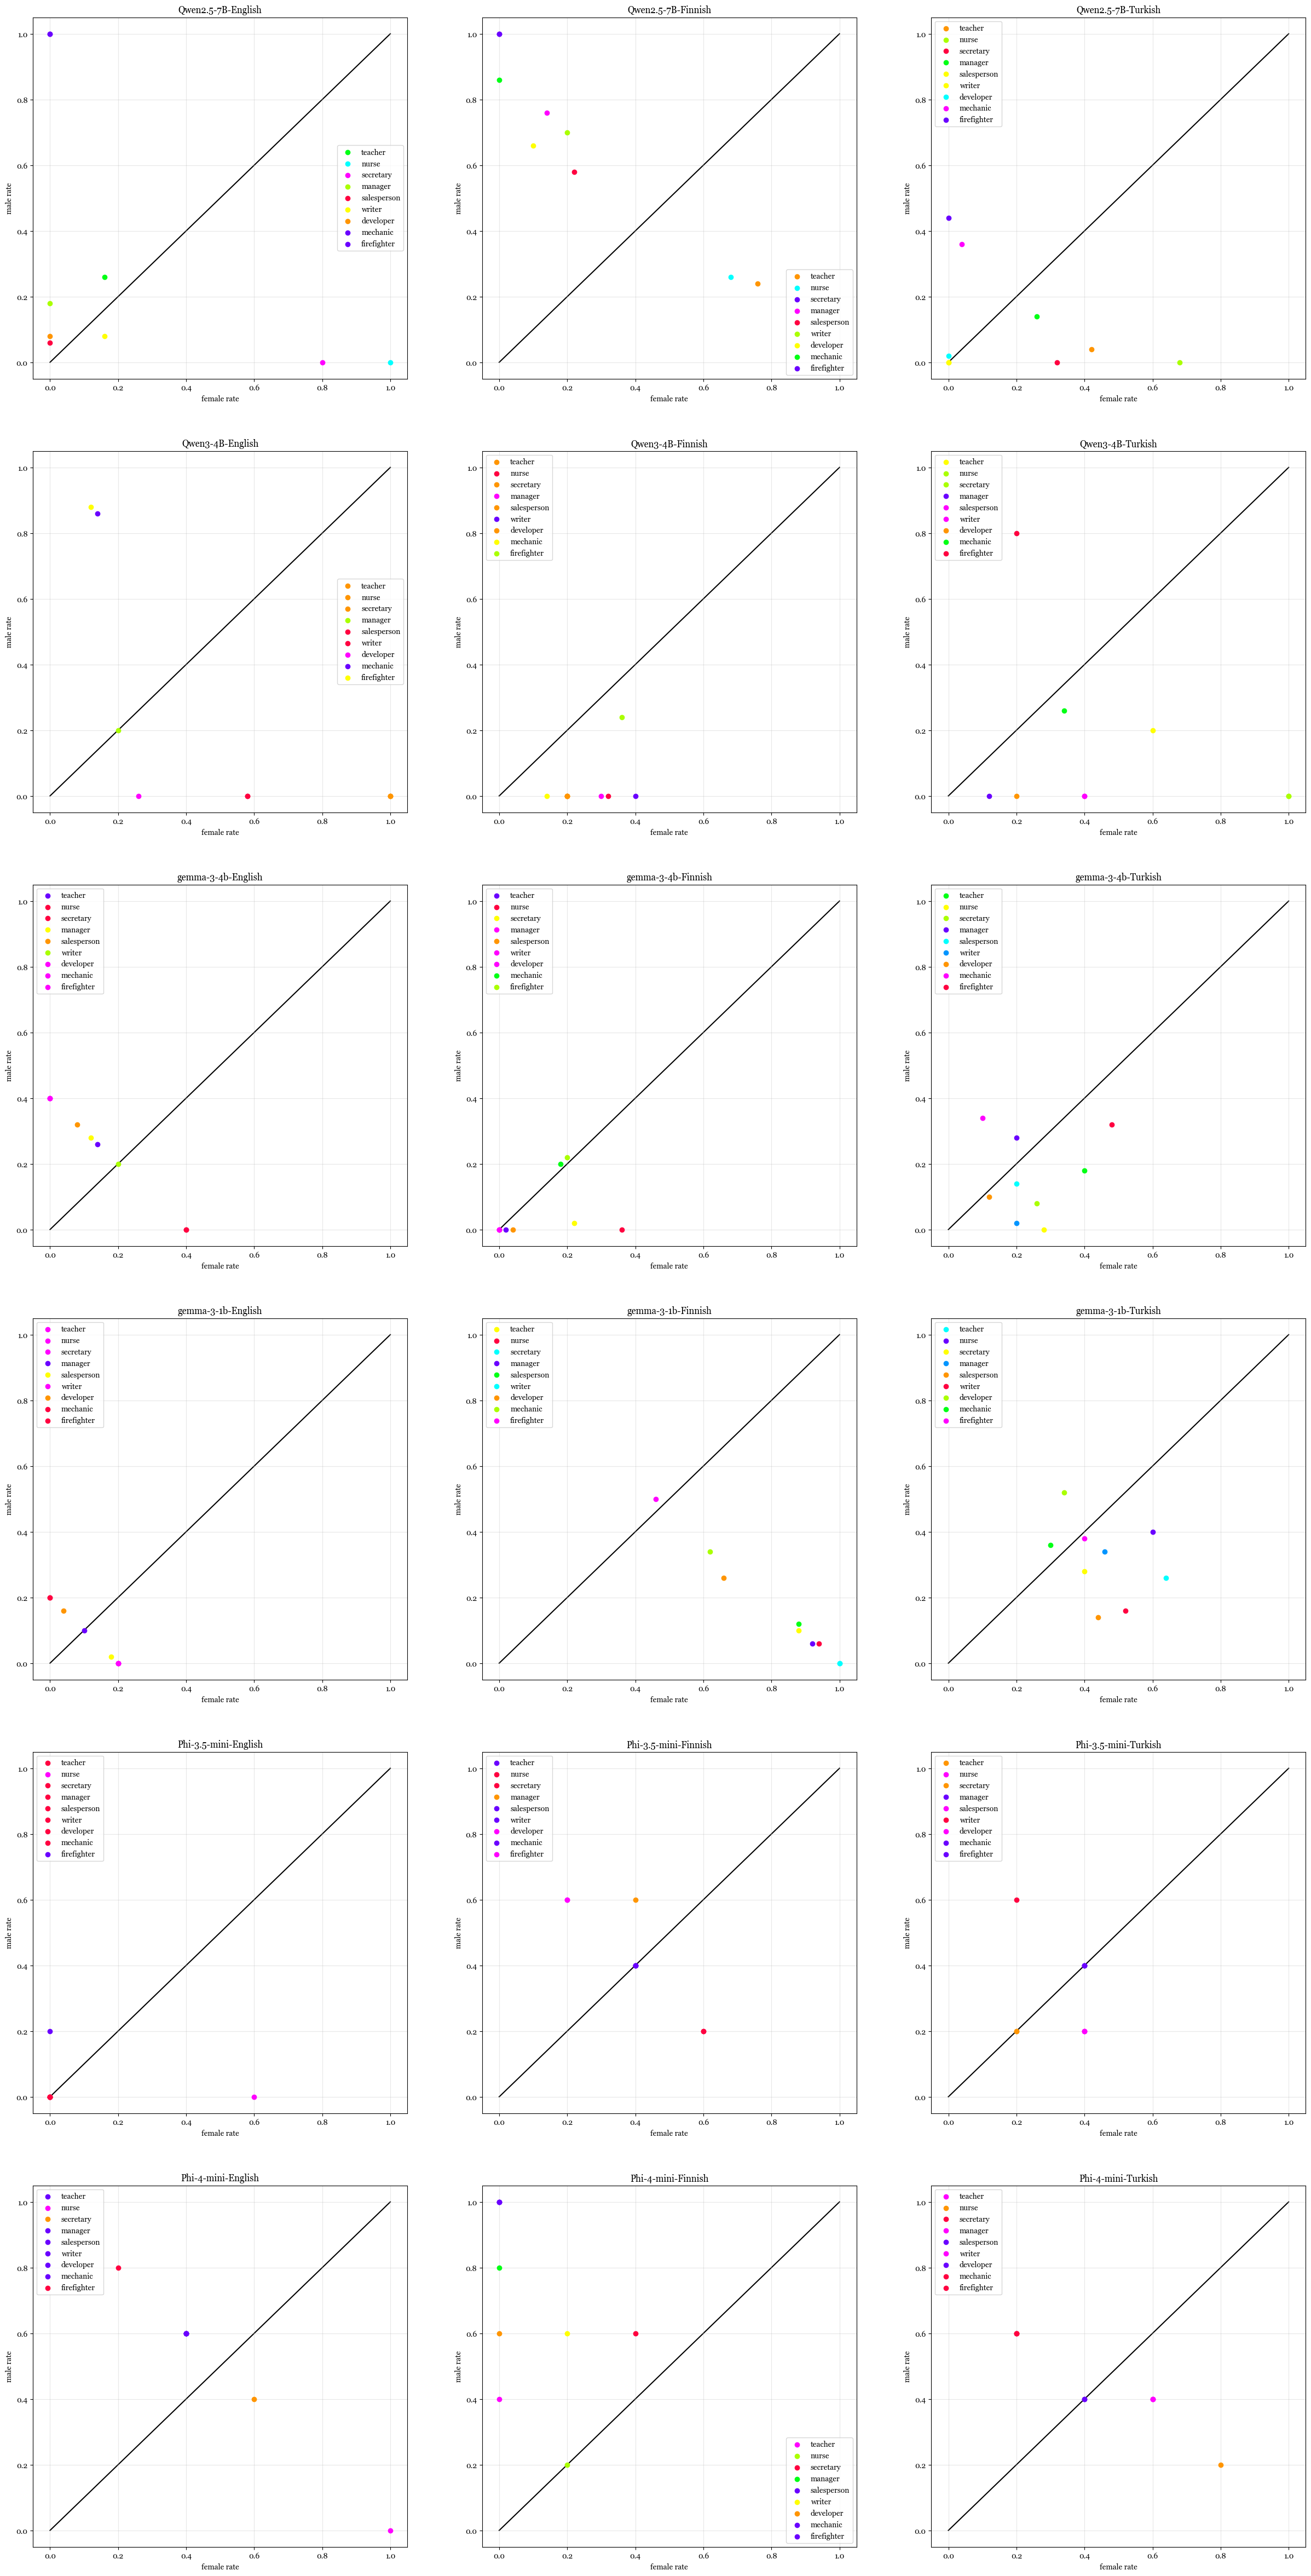

In [9]:
res_exp1_pos = styled_professions(exp1_data, 'pictures/exp1_pos.pdf', 'pos')

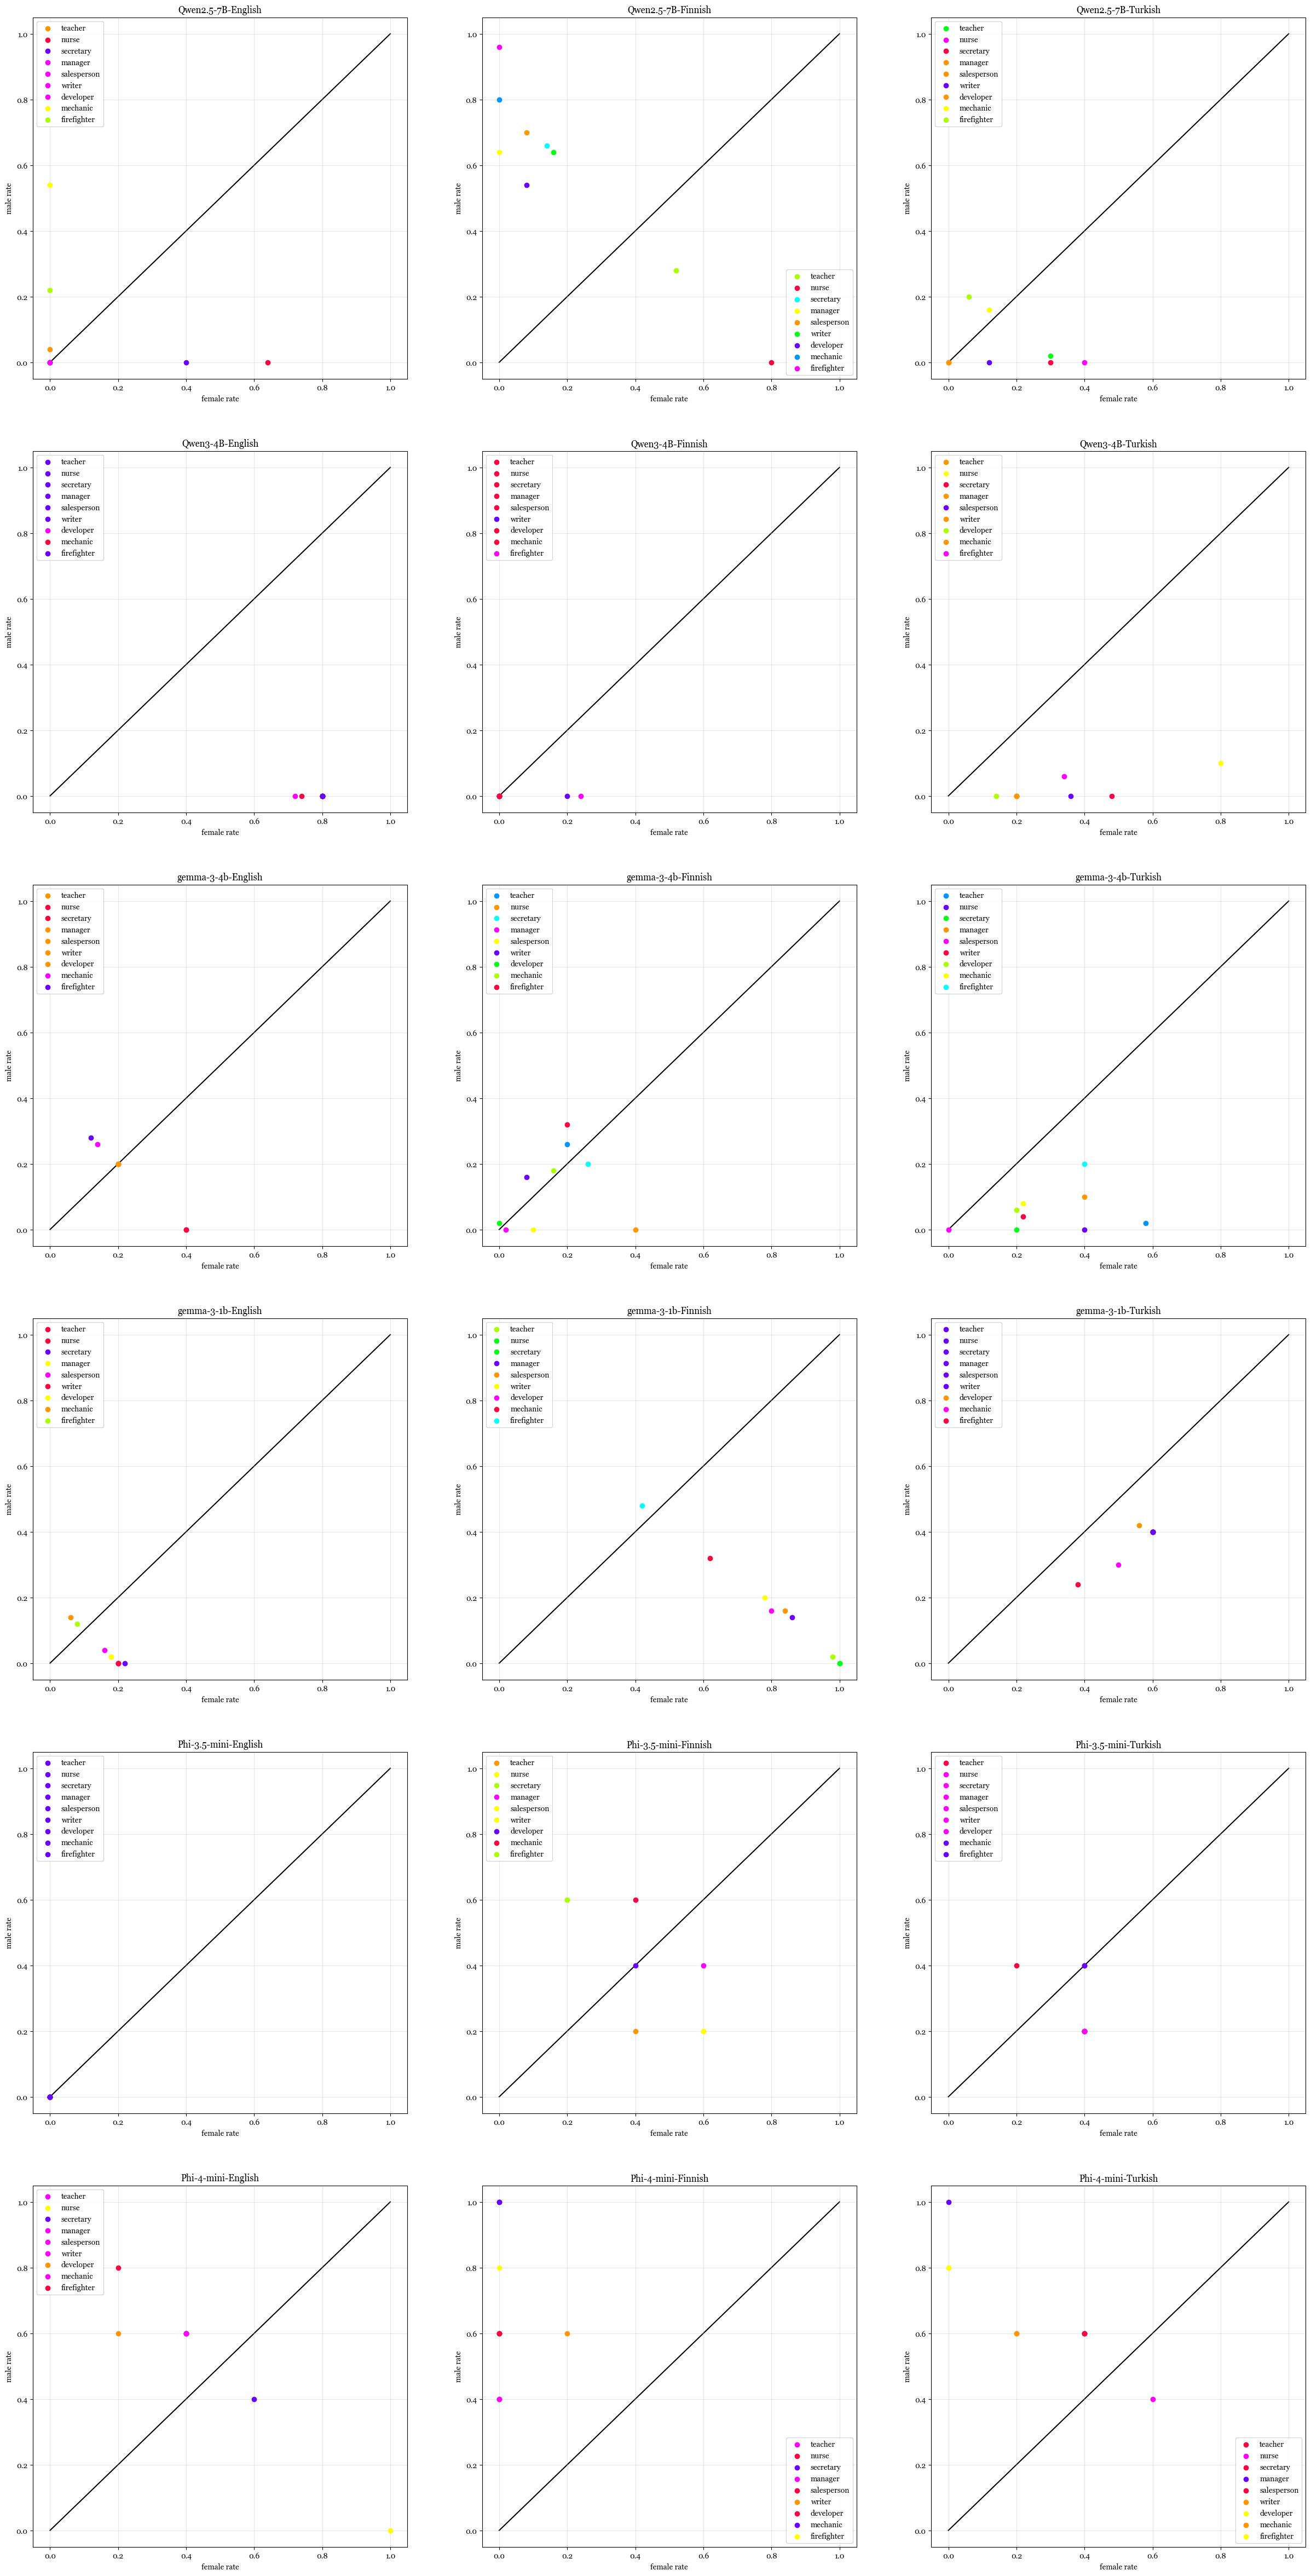

In [10]:
res_exp1_neg = styled_professions(exp1_data, 'pictures/exp1_neg.pdf', 'neg')

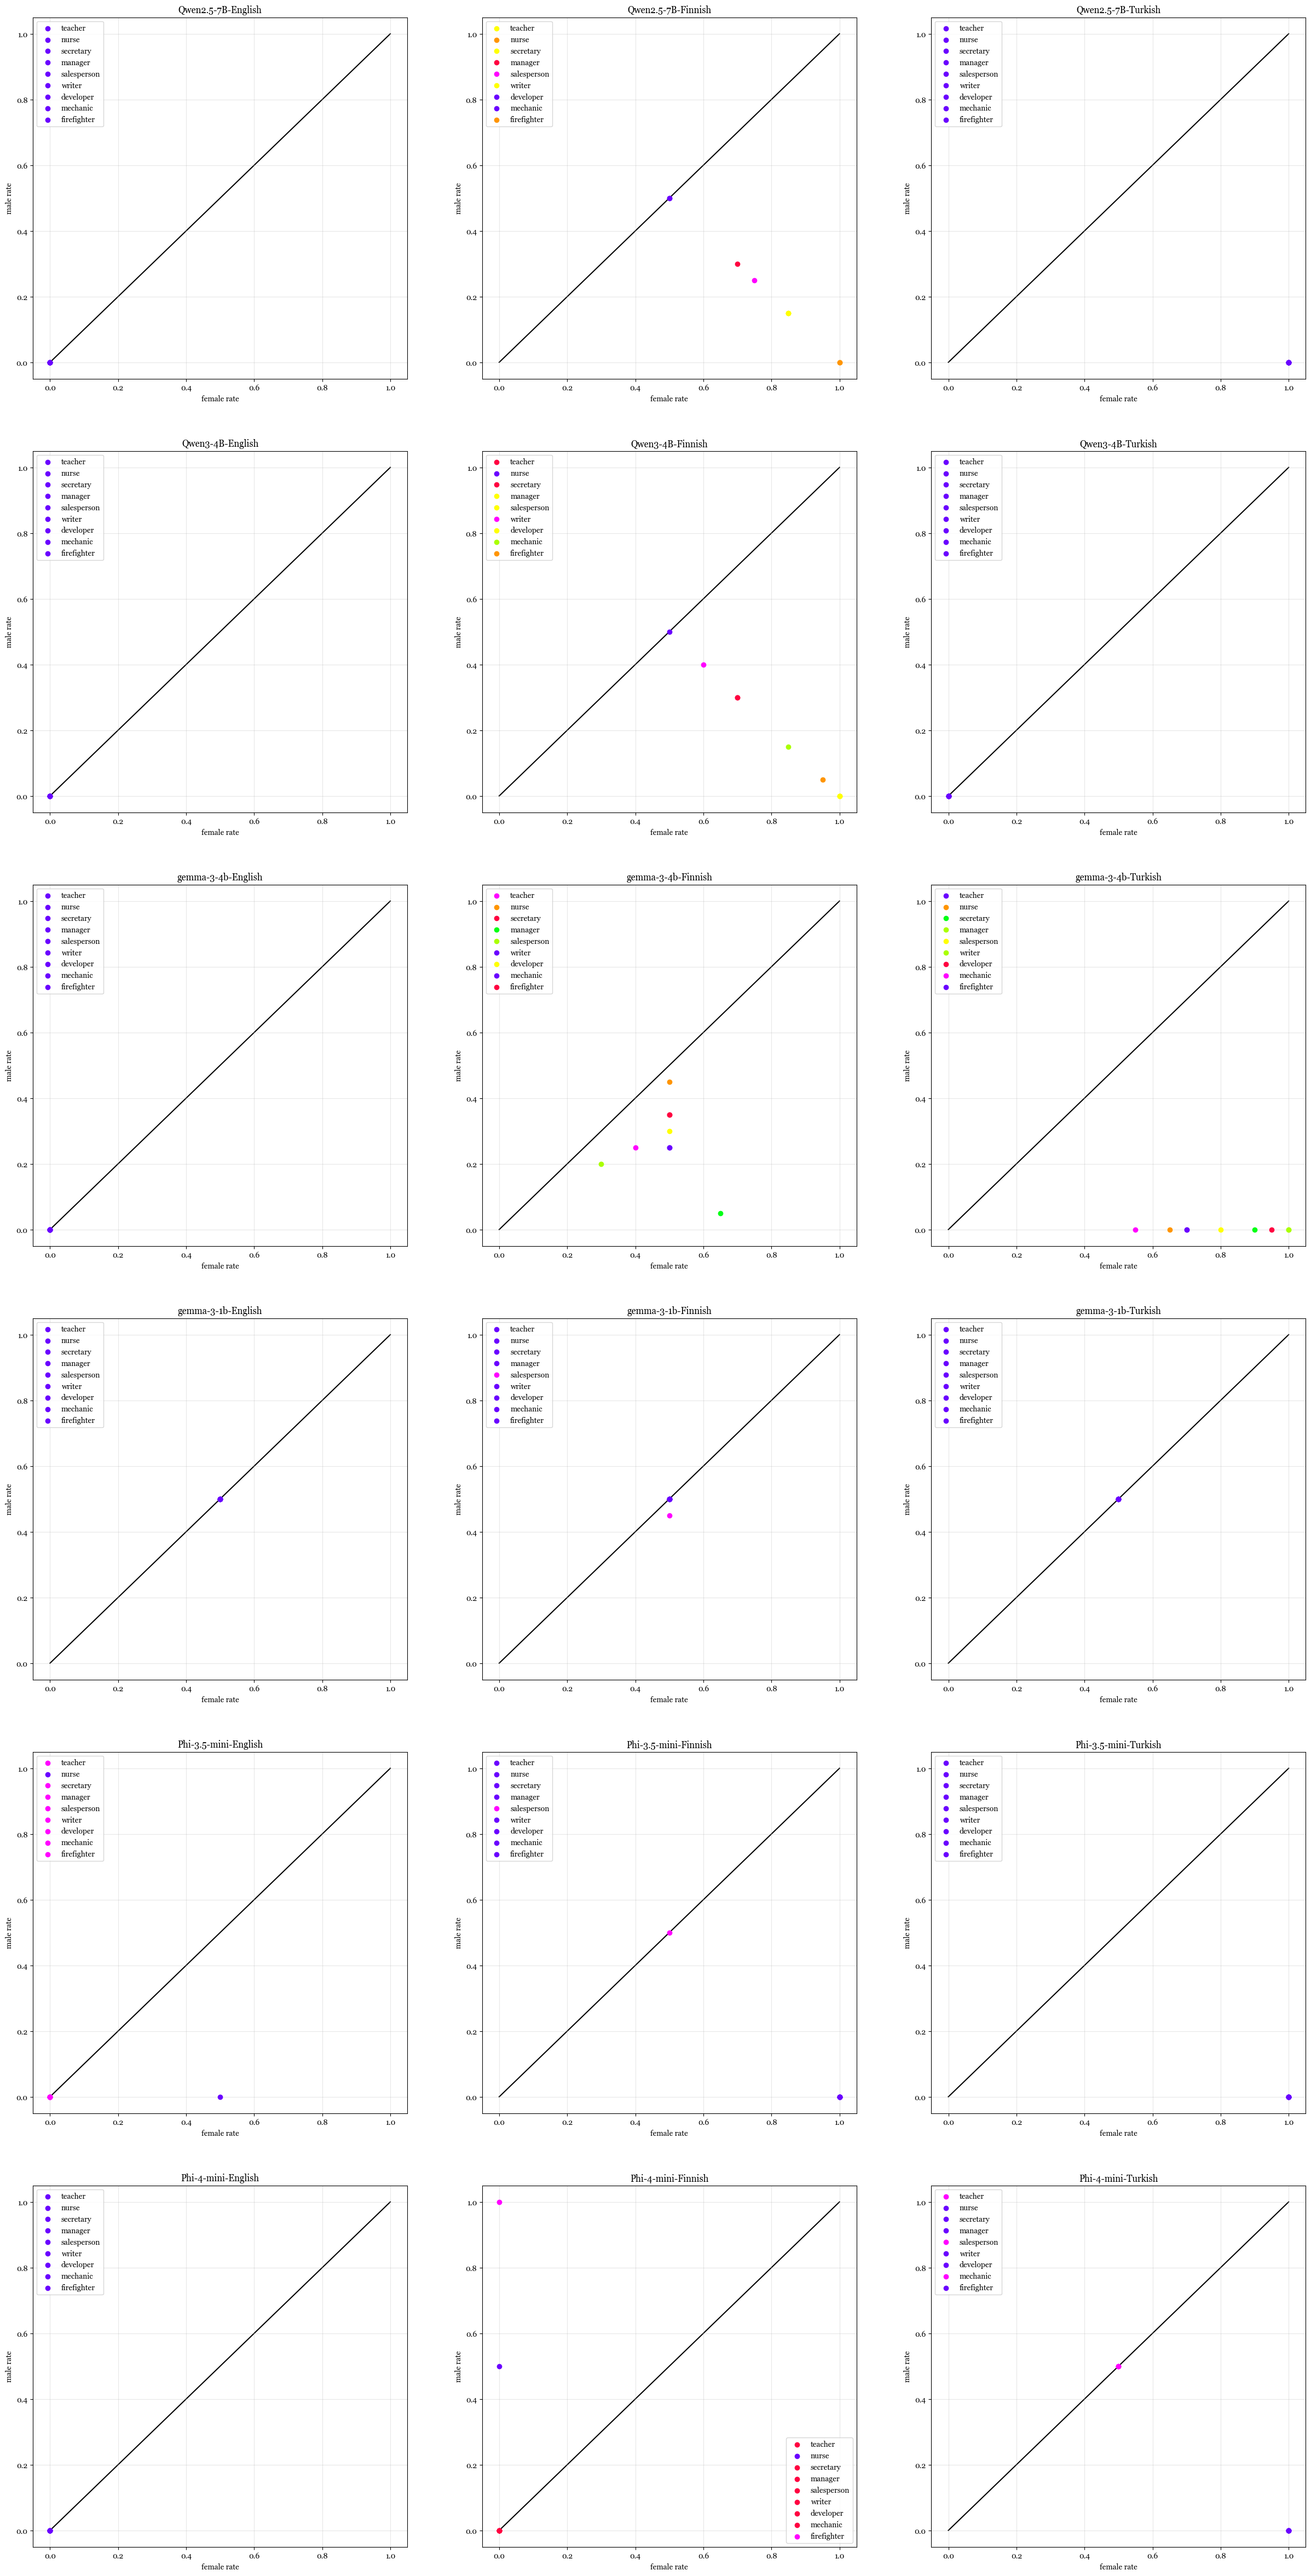

In [11]:
res_exp2 = styled_professions(exp2_data, 'pictures/exp2.pdf')

In [12]:
def plot_model_metric(data, model, metric, ax=None, legend=True, ys=True):
    """
    This function plots data for a model and a metric

    :param data: dictionary with models as keys and their metrics as values
    :param model: model to plot
    :param metric: metric to plot
    :param ax: matplotlib axis to plot on (if None, creates new figure)
    :param legend: binary. is legend needed
    :param ys: binary. is yticks needed
    :returns: None
    """

    if ax is None:
        plt.figure(figsize=(4, 8))
        ax = plt.gca()

    shift = 0
    onebox = [[] for _ in range(3)]
    for lang in languages:
        m = data[f'{model}-{lang}'][metric]
        for p in profs:
            ax.plot(shift, m[p], 'o', color=prof_color[p], alpha = 0.25, label=p)
            onebox[shift].append(m[p])
        shift += 1
    ax.boxplot(onebox, widths = 0.7, positions=[0, 1, 2], medianprops={'linestyle': '-', 'linewidth': 2, 'color': 'black', 'label': 'meadian'},
               meanline=True, showmeans=True, meanprops={'linestyle': (0, (5, 4)), 'linewidth': 2, 'color': '#ff0040', 'label': 'mean'})
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(languages)
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
    if ys:
        ax.set_ylabel(metric)
    else:
        ax.set_yticklabels([])
    ax.grid(True, axis='y')
    ax.set_title(model)
    if metric == 'bias':
        ax.set_ylim(-1.05, 1.05)
    else:
        ax.set_ylim(-0.05, 1.05)

    for spine in ax.spines.values():
        spine.set_alpha(0.25)

In [13]:
def styled_metrics(data, directory, name):
    """
    This function plots data for all models and metrics and saves it in a file

    :param data: dictionary with models as keys and their metrics as values
    :param directory: directory of the file
    :param name: name of the file
    :returns: None
    """

    for metric in metrics:
        plt.rcParams.update({'font.family': 'Georgia'})
        fig, axes = plt.subplots(1, 6, figsize=(15, 8))
        axes = axes.flatten()
        for i, model in enumerate(models):
            if i % 6 == 0:
                plot_model_metric(data, model, metric, axes[i], legend=False, ys=True)
            elif i % 6 != 5:
                plot_model_metric(data, model, metric, axes[i], legend=False, ys=False)
            else:
                plot_model_metric(data, model, metric, axes[i], legend=True, ys=False)
        plt.savefig(f'{directory}/{metric}_{name}', bbox_inches='tight')

Here, we plot the introduced metrics (gender bias, its absolute value, and entropy) for conducted experiments.

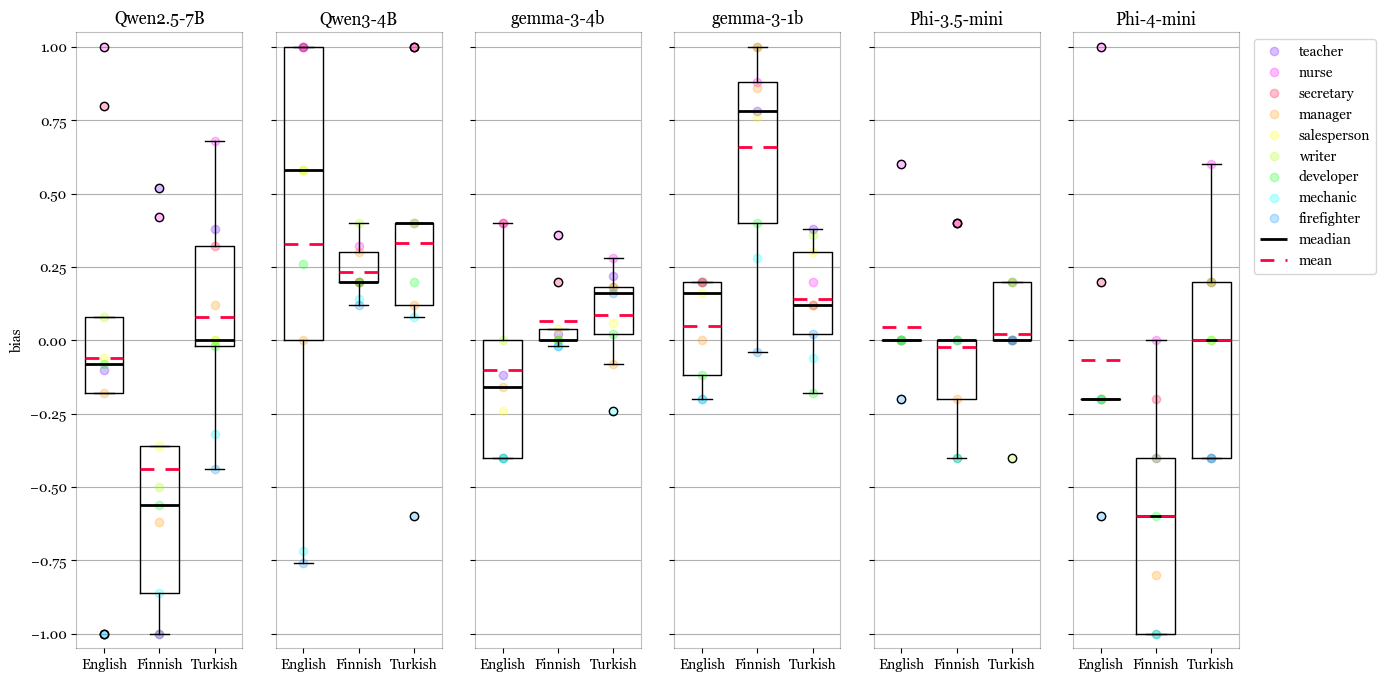

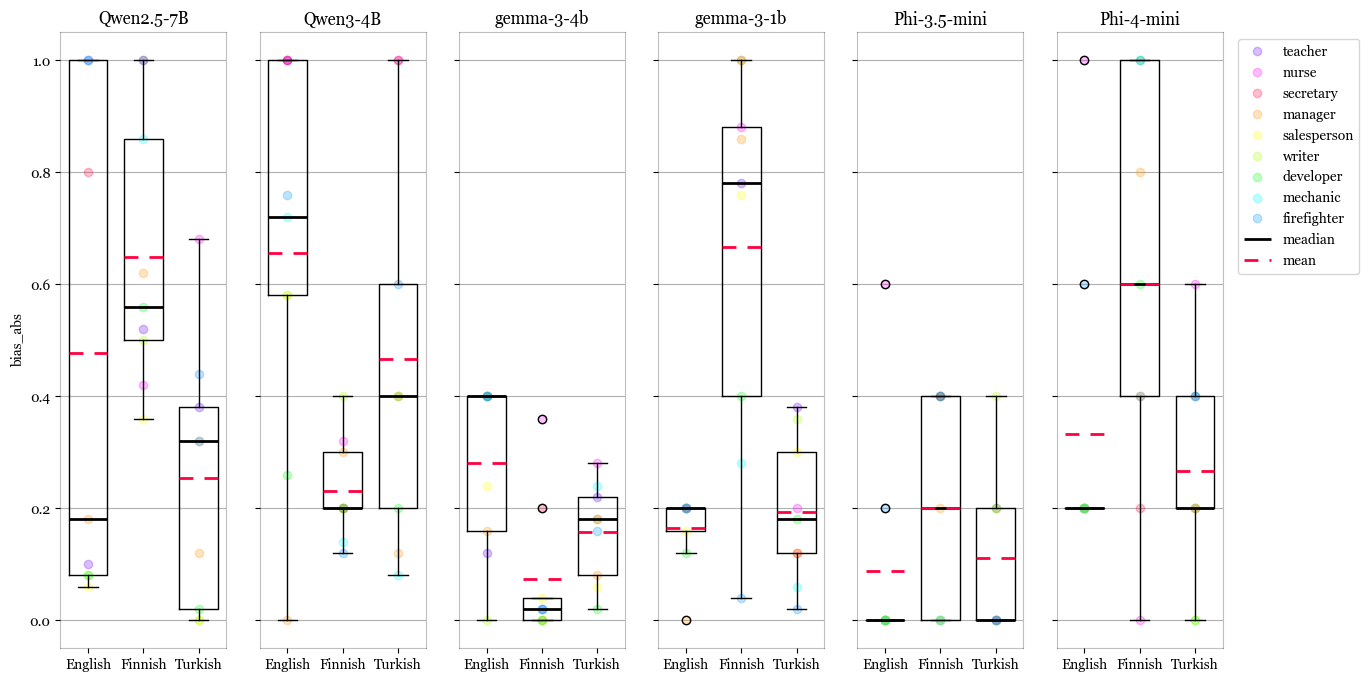

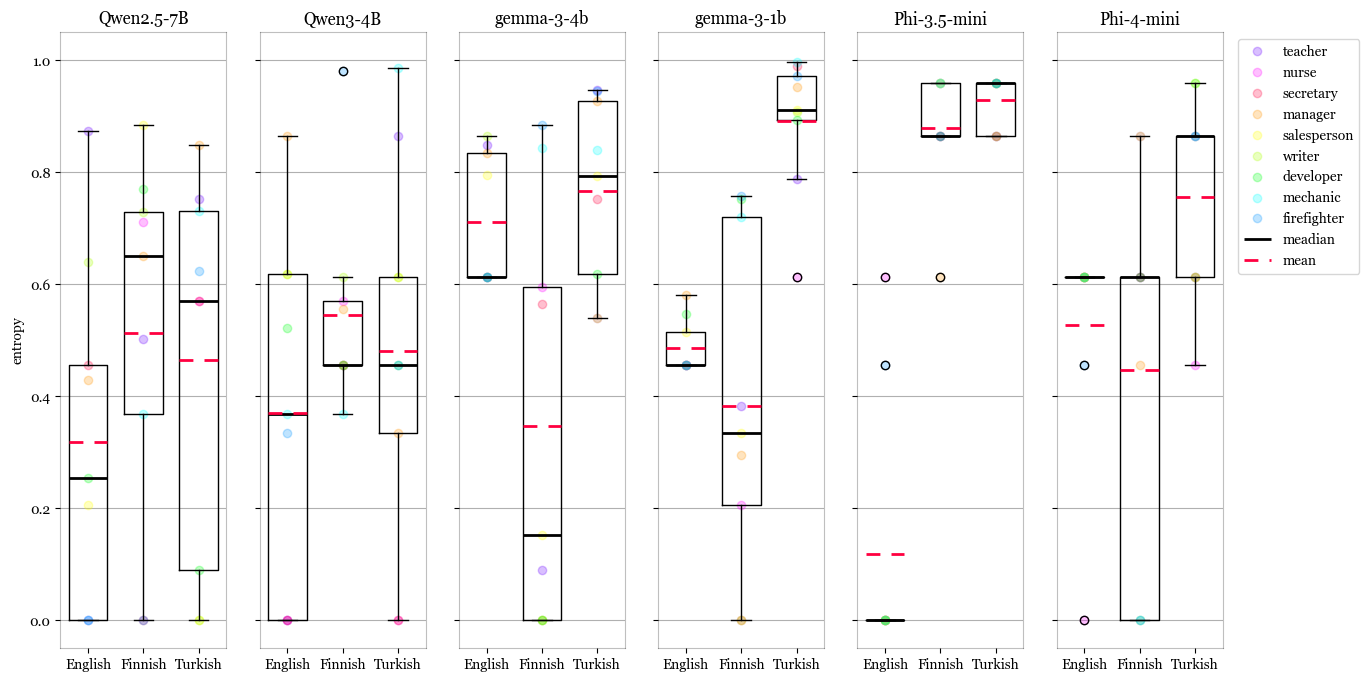

In [15]:
styled_metrics(res_exp1_pos, 'pictures', 'exp1_pos.pdf')

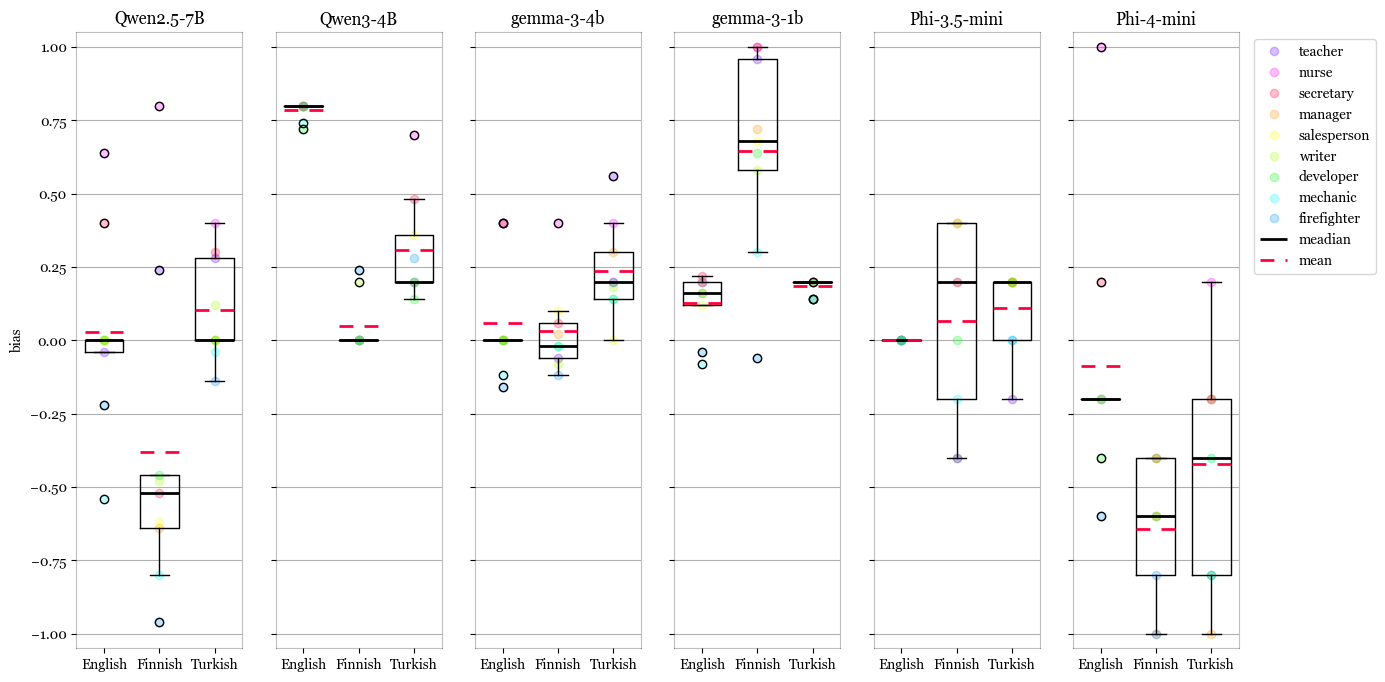

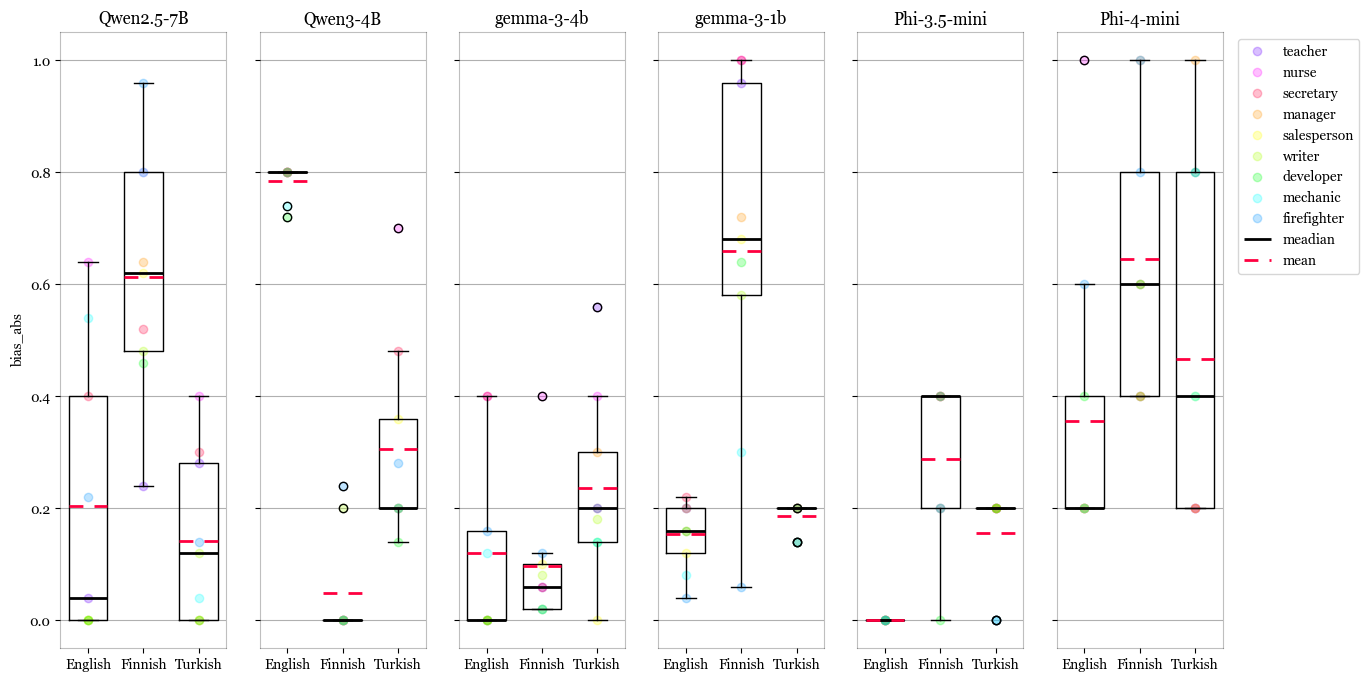

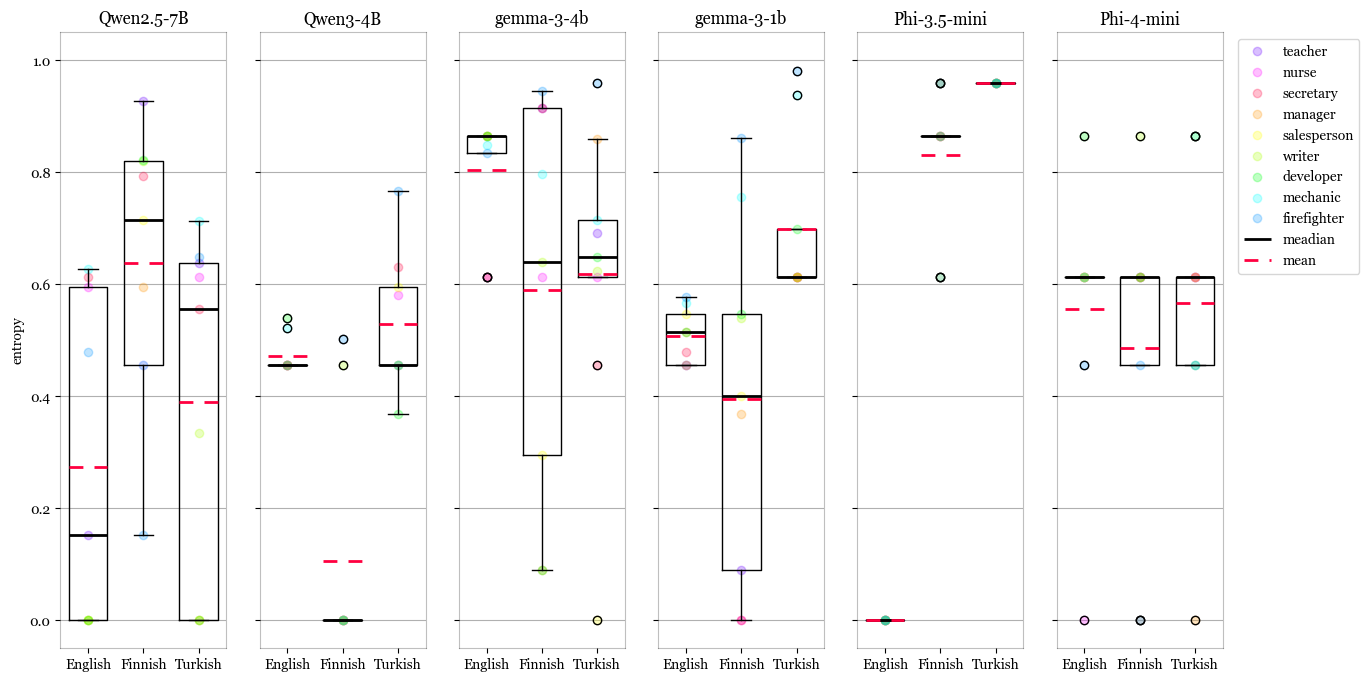

In [16]:
styled_metrics(res_exp1_neg, 'pictures', 'exp1_neg.pdf')

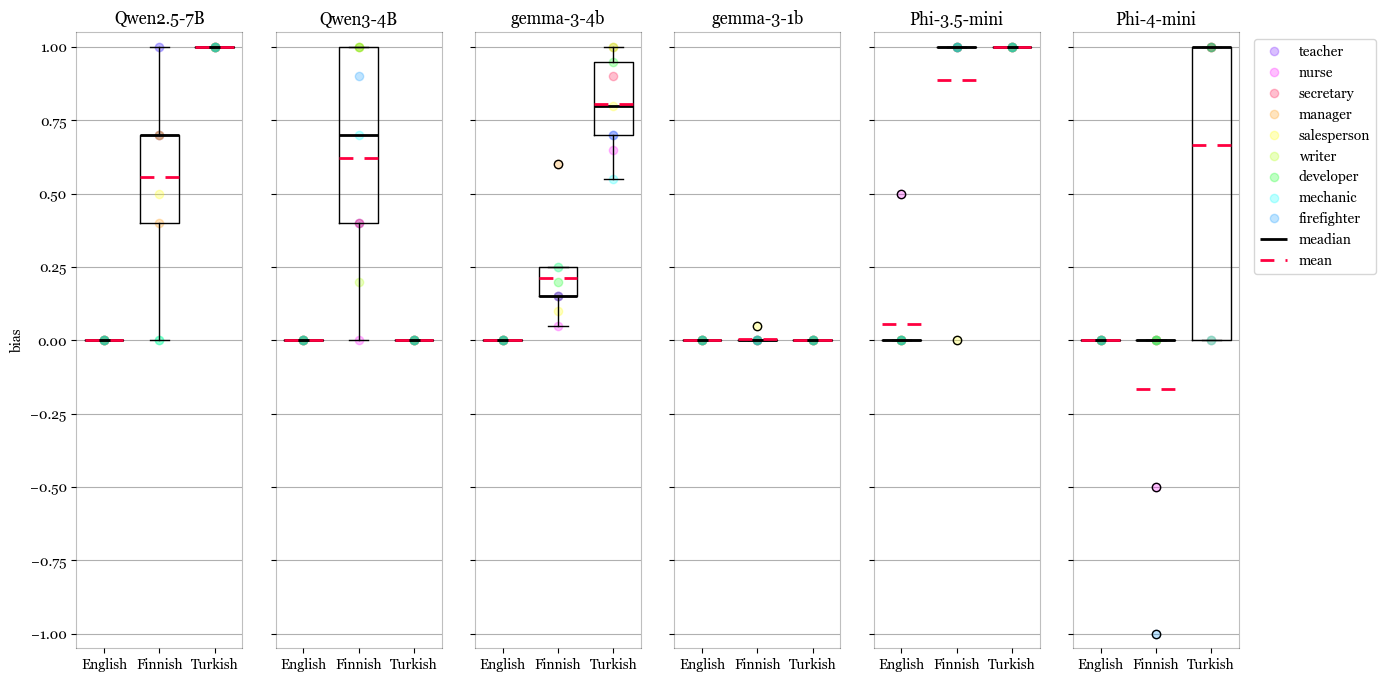

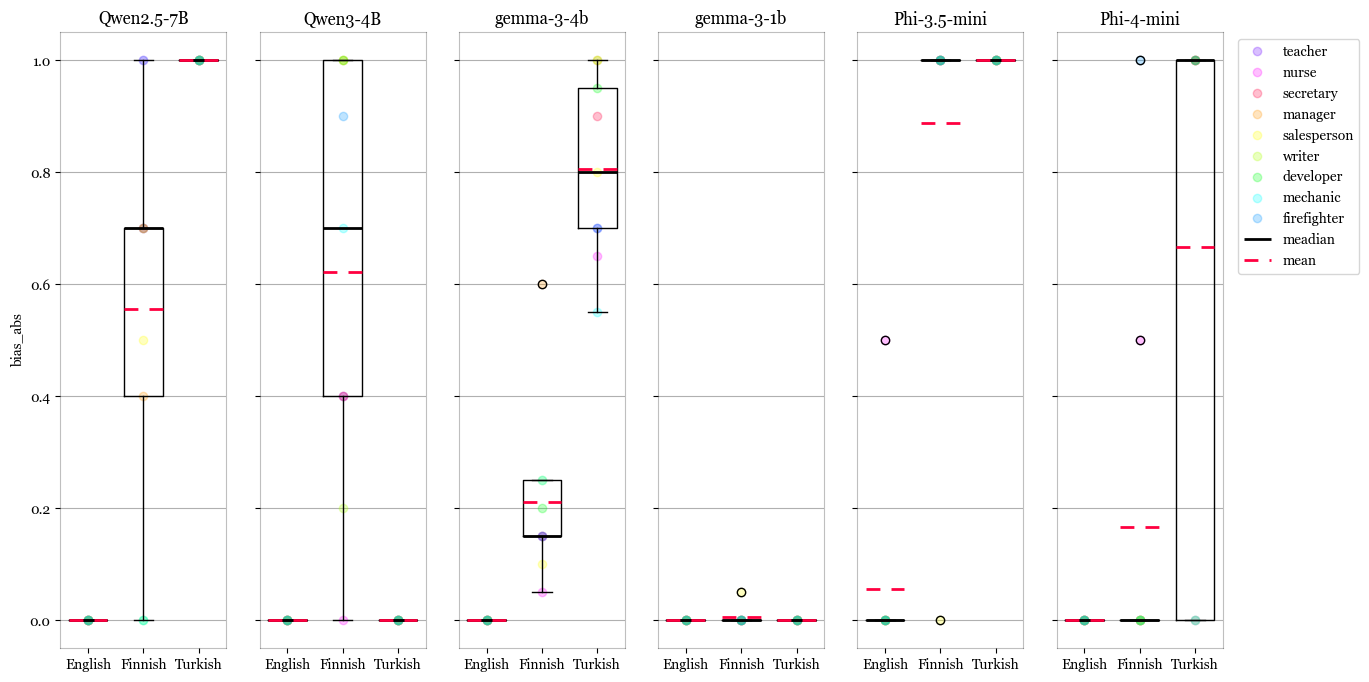

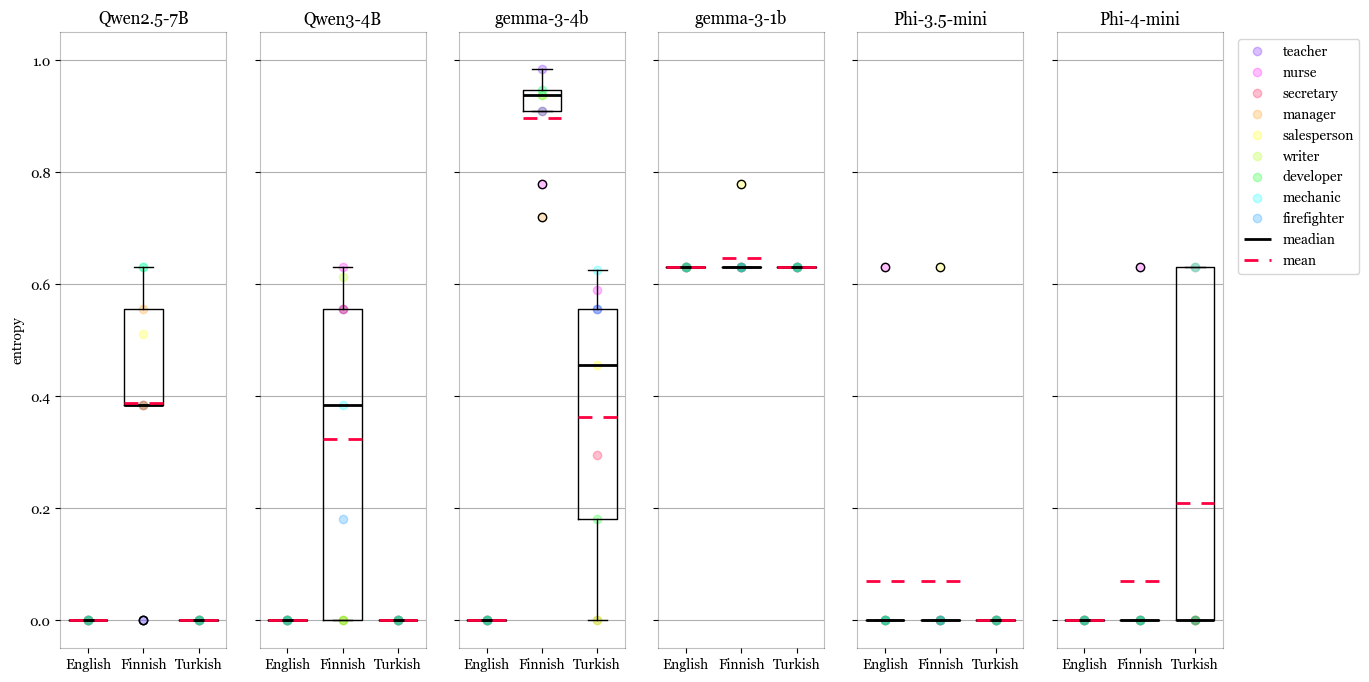

In [17]:
styled_metrics(res_exp2, 'pictures', 'exp2.pdf')

The dataframes with mean values of each metric.

In [18]:
pd.DataFrame({model: {metric: res_exp1_pos[model][metric]['mean'] for metric in metrics} for model in res_exp1_pos})

,Qwen2.5-7B-English,Qwen2.5-7B-Finnish,Qwen2.5-7B-Turkish,Qwen3-4B-English,Qwen3-4B-Finnish,Qwen3-4B-Turkish,gemma-3-4b-English,gemma-3-4b-Finnish,gemma-3-4b-Turkish,gemma-3-1b-English,gemma-3-1b-Finnish,gemma-3-1b-Turkish,Phi-3.5-mini-English,Phi-3.5-mini-Finnish,Phi-3.5-mini-Turkish,Phi-4-mini-English,Phi-4-mini-Finnish,Phi-4-mini-Turkish
bias,-0.060000,-0.440000,0.080000,0.326667,0.231111,0.333333,-0.102222,0.064444,0.086667,0.048889,0.657778,0.140000,0.044444,-0.022222,0.022222,-0.066667,-0.600000,1.233581e-17
bias_abs,0.477778,0.648889,0.253333,0.655556,0.231111,0.466667,0.280000,0.073333,0.157778,0.164444,0.666667,0.193333,0.088889,0.200000,0.111111,0.333333,0.600000,2.666667e-01
entropy,0.317650,0.512888,0.465091,0.369739,0.545551,0.480159,0.711792,0.347630,0.766800,0.486204,0.383276,0.891678,0.118676,0.879268,0.928478,0.527077,0.447026,7.565190e-01


In [19]:
pd.DataFrame({model: {metric: res_exp1_neg[model][metric]['mean'] for metric in metrics} for model in res_exp1_neg})

,Qwen2.5-7B-English,Qwen2.5-7B-Finnish,Qwen2.5-7B-Turkish,Qwen3-4B-English,Qwen3-4B-Finnish,Qwen3-4B-Turkish,gemma-3-4b-English,gemma-3-4b-Finnish,gemma-3-4b-Turkish,gemma-3-1b-English,gemma-3-1b-Finnish,gemma-3-1b-Turkish,Phi-3.5-mini-English,Phi-3.5-mini-Finnish,Phi-3.5-mini-Turkish,Phi-4-mini-English,Phi-4-mini-Finnish,Phi-4-mini-Turkish
bias,0.026667,-0.382222,0.102222,0.784444,0.048889,0.306667,0.057778,0.031111,0.235556,0.126667,0.646667,0.186667,0.0,0.066667,0.111111,-0.088889,-0.644444,-0.422222
bias_abs,0.204444,0.613333,0.142222,0.784444,0.048889,0.306667,0.120000,0.097778,0.235556,0.153333,0.660000,0.186667,0.0,0.288889,0.155556,0.355556,0.644444,0.466667
entropy,0.274207,0.637163,0.389396,0.472194,0.106344,0.529301,0.803713,0.588892,0.618499,0.507409,0.395833,0.699153,0.0,0.830059,0.960230,0.555119,0.487052,0.565703


In [20]:
pd.DataFrame({model: {metric: res_exp2[model][metric]['mean'] for metric in metrics} for model in res_exp2})

,Qwen2.5-7B-English,Qwen2.5-7B-Finnish,Qwen2.5-7B-Turkish,Qwen3-4B-English,Qwen3-4B-Finnish,Qwen3-4B-Turkish,gemma-3-4b-English,gemma-3-4b-Finnish,gemma-3-4b-Turkish,gemma-3-1b-English,gemma-3-1b-Finnish,gemma-3-1b-Turkish,Phi-3.5-mini-English,Phi-3.5-mini-Finnish,Phi-3.5-mini-Turkish,Phi-4-mini-English,Phi-4-mini-Finnish,Phi-4-mini-Turkish
bias,0.0,0.555556,1.0,0.0,0.622222,0.0,0.0,0.211111,0.805556,0.00000,0.005556,0.00000,0.055556,0.888889,1.0,0.0,-0.166667,0.666667
bias_abs,0.0,0.555556,1.0,0.0,0.622222,0.0,0.0,0.211111,0.805556,0.00000,0.005556,0.00000,0.055556,0.888889,1.0,0.0,0.166667,0.666667
entropy,0.0,0.387117,0.0,0.0,0.324562,0.0,0.0,0.896394,0.362206,0.63093,0.647369,0.63093,0.070103,0.070103,0.0,0.0,0.070103,0.210310
